In [1]:
!pip install openai numpy tensorflow matplotlib logging scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3

In [2]:
# Cell 1: Imports & Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import logging
from openai import OpenAI

# Configure logging
logging.basicConfig(filename="results.log",
                    level=logging.INFO,
                    format="%(asctime)s - %(message)s")

# Initialize OpenAI client
client = OpenAI()

In [3]:
# Cell 2: Load dataset (Digits dataset from scikit-learn)
digits = load_digits()
X = digits.data
y = digits.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Cell 3: Train a simple classifier
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.92      0.96      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.98       360



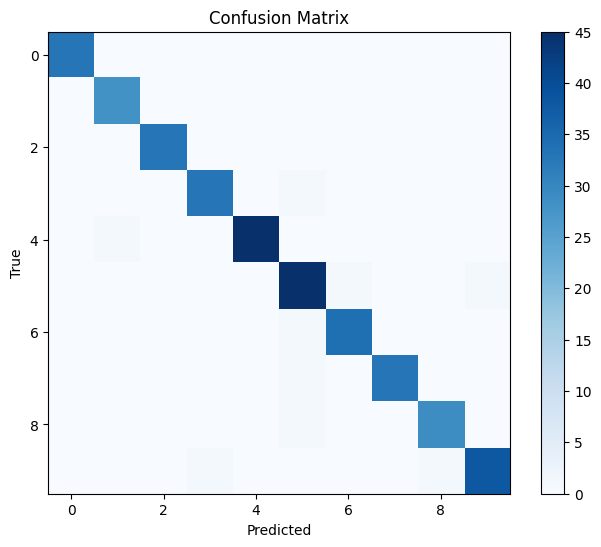

In [5]:
# Cell 4: Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

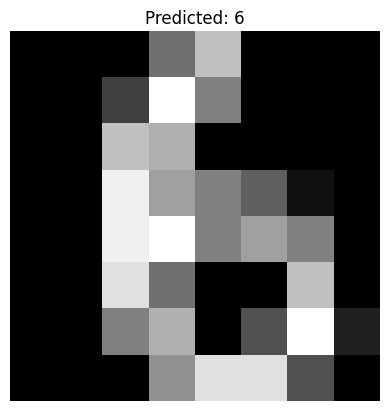

Predicted class: 6
OpenAI Explanation: Sure! Here’s a simple explanation of how **logistic regression** works for classification, like recognizing digits:

1. **What is logistic regression?**  
   It's a method used to predict categories (like digits 0, 1, 2, ..., 9) based on input features (like pixel values of an image).

2. **How does it work?**  
   - Imagine you have a lot of images of handwritten digits. Each image is turned into a list of numbers (features) representing pixels.  
   - Logistic regression assigns weights to each feature. These weights tell the model how important each pixel is for predicting a certain digit.  
   - It then combines (multiplies and adds) these weighted inputs into a single number called a "score."

3. **From scores to probabilities:**  
   - The model applies a special function called the **logistic (or sigmoid) function** to this score, which squeezes it into a value between 0 and 1.  
   - This value is interpreted as the probability that the im

In [6]:
# Cell 5: Predict a sample and explain with OpenAI
sample_idx = 0
sample = X_test[sample_idx].reshape(1, -1)
prediction = clf.predict(sample)[0]

plt.imshow(X_test[sample_idx].reshape(8,8), cmap="gray")
plt.title(f"Predicted: {prediction}")
plt.axis("off")
plt.show()

print("Predicted class:", prediction)

# Ask OpenAI to explain
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": f"The scikit-learn model predicted '{prediction}' for a digit image. Explain how logistic regression works for classification in simple terms."}
    ]
)

explanation = response.choices[0].message.content
print("OpenAI Explanation:", explanation)

# Log results
logging.info(f"Prediction: {prediction}, Explanation: {explanation}")